# Caffeine Postlab Analysis

In [3]:
import numpy as np
from datascience import *
import math as m

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Step 1: Import your data by applying the following steps:
1. Download the caffeine .csv file from your group's Canvas submission.
2. In the file directory to the left, check to see that you are in the same folder as this notebook. You can also right-click this page's tab above and select 'Show in File Browser' if you find it hard to navigate.
3. Click the Upload button (Up arrow with underline) in the top of the File Directory, and select your .csv file. The file should pop up in the directory.
4. Type in the relevant code below to import your caffeine data.

In [4]:
# Hint: Check Lab 3
caffeine_data = Table.read_table('Caffeine Stdrds w Tea Samples.csv')
caffeine_data

DI Water:Wavelength(nm),DI Water:Absorbance,40.7 uM:Wavelength(nm),40.7 uM:Absorbance,4.07 uM:Wavelength(nm),4.07 uM:Absorbance,20.3 uM:Wavelength(nm),20.3 uM:Absorbance,60 uM:Wavelength(nm),60 uM:Absorbance,90 uM:Wavelength(nm),90 uM:Absorbance,122 uM:Wavelength(nm),122 uM:Absorbance,Black Tea 1/100 dilution:Wavelength(nm),Black Tea 1/100 dilution:Absorbance,Green/Blueberry Tea 1/100 dilution:Wavelength(nm),Green/Blueberry Tea 1/100 dilution:Absorbance
220.8,0.00423644,220.8,0.358982,220.8,-0.00307204,220.8,0.173068,220.8,0.387804,220.8,0.656378,220.8,0.807666,220.7,0.92957,220.7,1.15286
221.8,0.00359672,221.8,0.351306,221.8,-0.00415511,221.8,0.169849,221.8,0.377676,221.8,0.639768,221.8,0.792264,221.6,0.912738,221.6,1.10583
222.8,0.00430812,222.8,0.33706,222.8,-0.00527824,222.8,0.164686,222.8,0.362715,222.8,0.611834,222.8,0.765125,222.6,0.871731,222.6,1.04618
223.7,0.00338239,223.7,0.325938,223.7,-0.00530507,223.7,0.160735,223.7,0.350164,223.7,0.588707,223.7,0.742481,223.6,0.843404,223.6,1.00922
224.7,0.00281666,224.7,0.317957,224.7,-0.00534019,224.7,0.157079,224.7,0.340467,224.7,0.570824,224.7,0.719815,224.5,0.814278,224.5,0.974725
225.6,0.00192958,225.6,0.309759,225.6,-0.00538983,225.6,0.153385,225.6,0.331411,225.6,0.555807,225.6,0.696292,225.5,0.786521,225.5,0.93858
226.6,0.00125047,226.6,0.301217,226.6,-0.00567923,226.6,0.14906,226.6,0.322296,226.6,0.541415,226.6,0.674838,226.5,0.762255,226.5,0.906862
227.5,0.00151992,227.5,0.292378,227.5,-0.00525679,227.5,0.145594,227.5,0.314888,227.5,0.527381,227.5,0.656829,227.4,0.741492,227.4,0.878256
228.5,0.00185746,228.5,0.284321,228.5,-0.00497013,228.5,0.141981,228.5,0.305347,228.5,0.511222,228.5,0.635629,228.4,0.727879,228.4,0.854464
229.5,0.00255063,229.5,0.276039,229.5,-0.00563075,229.5,0.138238,229.5,0.294699,229.5,0.493683,229.5,0.611241,229.3,0.715345,229.3,0.827011


This wonderful cell right below will graph all the spectrums of your data (assuming that they are of the correct order). If your table is of a different format, don't worry about troubleshooting this cell. However, if this does work correctly, you should see a beautiful kaleidescope of colors. :)

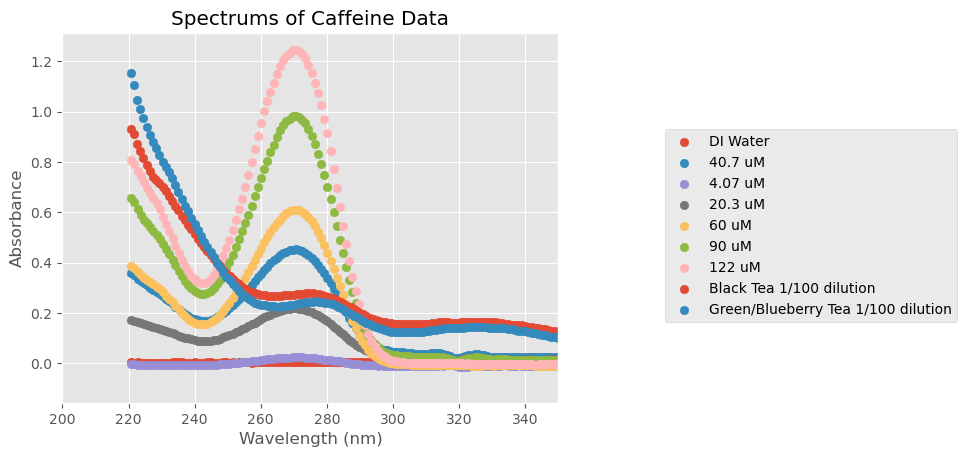

In [74]:
for i in np.arange(caffeine_data.num_columns/2):
    plt.scatter(caffeine_data[int(2*i)], caffeine_data[int(2*i+1)], label=caffeine_data.labels[int(2*i+1)].split(':')[0])
plt.legend(bbox_to_anchor = (1.2, 0.2))
plt.xlim(200, 350)
plt.title('Spectrums of Caffeine Data')
plt.ylabel('Absorbance')
plt.xlabel('Wavelength (nm)')
plt.show()

If it works, record all that you notice about the spectrums. What patterns do you see among the caffeine standards? Is this pattern upheld by the unknown solutions?

**<Replace this line with your response!>**

## Step 2: Graphical Analysis
In analyzing substances with a UV/Vis spectrophotometer, each substance absorbs electromagnetic radiation of a certain wavelength. When looking at that specific wavelength, called $\lambda_{max}$, the Absorbance is proportional to the concentration of that substance. That is, the more stuff there is, the more radiation will be absorbed.

Caffeine absorbs best at a wavelength of 270 nanometers. For each of your trials, Get the reading that most closely has a wavelength of 270 nm, and compile these readings into a table. 

Hints:
* Even though your readings may not be exactly at 270 nm, they will be close (e.g. 270.6 nm). What table method do you use to get rows whose wavelengths are closest to but not exactly 270 nm?
* You likely won't have to worry about filtering for every single spectrum; assuming you didn't change the spectrophotometer's settings between trials, all the measurements closest to 270 nm should lie on the same row or same few rows.
* Ignore the Unknown solutions for now; those will come back in Step 5.

The result should look something like this (with the ...'s representing the absorbances around 270 nm):

|Concentration|Absorbance|
|--|--|
|4.07|...|
|20.3|...|
|40.7|...|
|60|...|
|90|...|
|122|...|

In [55]:
nearest_readings = caffeine_data.where(2, are.between(269, 271))
nearest_readings

DI Water:Wavelength(nm),DI Water:Absorbance,40.7 uM:Wavelength(nm),40.7 uM:Absorbance,4.07 uM:Wavelength(nm),4.07 uM:Absorbance,20.3 uM:Wavelength(nm),20.3 uM:Absorbance,60 uM:Wavelength(nm),60 uM:Absorbance,90 uM:Wavelength(nm),90 uM:Absorbance,122 uM:Wavelength(nm),122 uM:Absorbance,Black Tea 1/100 dilution:Wavelength(nm),Black Tea 1/100 dilution:Absorbance,Green/Blueberry Tea 1/100 dilution:Wavelength(nm),Green/Blueberry Tea 1/100 dilution:Absorbance
269.6,0.00500214,269.6,0.451268,269.6,0.0239409,269.6,0.218393,269.6,0.608352,269.6,0.981268,269.6,1.24452,269.9,0.272976,269.9,0.23328
270.6,0.00495964,270.6,0.452373,270.6,0.0236557,270.6,0.218735,270.6,0.61073,270.6,0.9823,270.6,1.24476,270.8,0.274513,270.8,0.235796


In [17]:
abs_at_lambda_max = Table().with_columns('Concentration (um)', [4.07, 20.3, 40.7, 60, 90, 122], 'Absorbance', [nearest_readings[5][0], nearest_readings[7][0], nearest_readings[3][0], nearest_readings[9][0], nearest_readings[11][0], nearest_readings[13][0]])
abs_at_lambda_max

Concentration (um),Absorbance
4.07,0.0239409
20.3,0.218393
40.7,0.451268
60,0.608352
90,0.981268
122,1.24452


Take a look at the output of this following cell: it shows a scatter plot, with the concentration on the x-axis and the absorbance at $\lambda_{max}$ at on the y-axis.

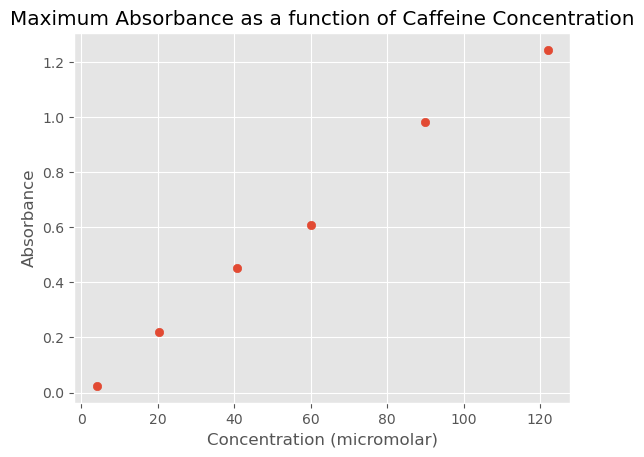

In [18]:
plt.scatter(abs_at_lambda_max[0], abs_at_lambda_max[1])
plt.title('Maximum Absorbance as a function of Caffeine Concentration')
plt.ylabel('Absorbance')
plt.xlabel('Concentration (micromolar)')
plt.show()

Does there seem to be a relationship between the two variables? If so, what kind (linear, square, inverse, etc.)? 

Are there any outliers (points that do not seem to fit the overall trend)? If so, what could be causing this?

**<Double-click on this cell and replace this line with your response!>**

## Step 3: Best Fit: Slope
The standard way to measure the correlation between two numerical variables is to compute the best fit line of the data. This best fit line is in the format
$$y = mx + b$$
where
* x is the variable of the x-axis (concentration)
* y is the variable of the y-axis (absorbance)
* m is the slope (that is, how much does a change in x change y?)
* b is the intercept (that is, if x were 0, what would y be?)

While there are many ways to get the best fit, a common way (and the way that Excel and others do it) is with something called the **Least Squares Method**.

We can get m through the following formula:

$$m = \frac{n\Sigma(x_iy_i)-\Sigma(x_i)\Sigma(y_i)}{n\Sigma(x^2_i)-(\Sigma(x_i))^2}$$

where 
* $x_i$ and $y_i$ represent the x value and y value at position i, respectively
* $\Sigma$ is just a fancy way of writing sum. So, $\Sigma(x_i)$ means that you are adding up all the x values
* $n$ is the number of terms.

Hints:
* This looks very daunting; go one block at a time! You do not have to do everything in a single line of code. Use variables to store the result of each block and then just combine them together at the end.
* $\Sigma(x_iy_i)$ means that you are multiplying the x at some position with the y at that same position prior to summing these products up. How can you do this first operation (called element-wise operation) without much hassle?
* Be very careful not to mix up $\Sigma(x^2_i)$ and $(\Sigma(x_i))^2$. Use the order of operations to deduce what operation goes first.

In [19]:
n = abs_at_lambda_max.num_rows

# numerator terms
sum_xy = sum(abs_at_lambda_max[0] * abs_at_lambda_max[1])
sum_x = sum(abs_at_lambda_max[0])
sum_y = sum(abs_at_lambda_max[1])

numerator = n * sum_xy - sum_x * sum_y

# denominator terms
sum_x2 = sum(abs_at_lambda_max[0]**2)
# the sum_x from numerator will be used for the rightmost term

denominator = n * sum_x2 - sum_x**2

slope = numerator/denominator

slope

0.010414086181711791

## Step 4: Best Fit: Intercept
Now that you've found the slope, the equation $y = mx + b$ now only has one unknown value. Using your nifty algebra skills, rearrange the equation for $b$ and solve for it. Use the averages of x and y for the $x$ and $y$ in this equation.

In [20]:
intercept = np.mean(abs_at_lambda_max[1]) - slope * np.mean(abs_at_lambda_max[0])
intercept

0.0029108760409947143

Now, assuming you've assigned the slope and intercept to the relevant variable names, run this cell below to see your fit line in relation to the data. Does it look accurate? 

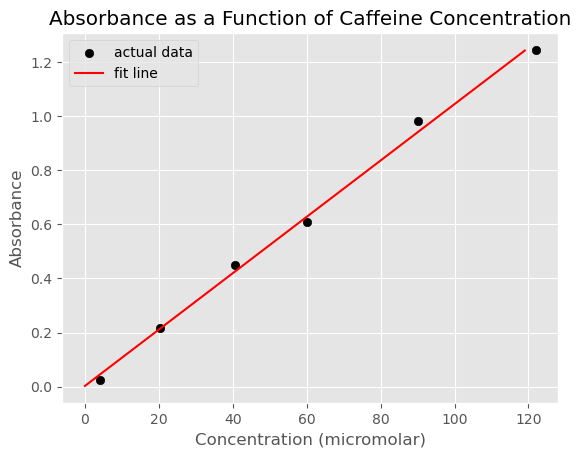

In [57]:
plt.scatter(abs_at_lambda_max[0], abs_at_lambda_max[1], color = 'black', label = 'actual data')
plt.plot(np.arange(0, 120), [slope * x + intercept for x in np.arange(0, 120)], color = 'red', label = 'fit line')
plt.legend()
plt.title('Absorbance as a Function of Caffeine Concentration')
plt.ylabel('Absorbance')
plt.xlabel('Concentration (micromolar)')
plt.show()

## Step 5: Determination of the Unknown Concentration
Now we come to the real problem: What was the concentration of caffeine in the unknown solution of tea?

You will remember that you had collected the absorbance of this unknown solution. Use the same code as Step 3 to get the absorbance just at that $\lambda_{max}$.

In [25]:
nearest_readings

DI Water:Wavelength(nm),DI Water:Absorbance,40.7 uM:Wavelength(nm),40.7 uM:Absorbance,4.07 uM:Wavelength(nm),4.07 uM:Absorbance,20.3 uM:Wavelength(nm),20.3 uM:Absorbance,60 uM:Wavelength(nm),60 uM:Absorbance,90 uM:Wavelength(nm),90 uM:Absorbance,122 uM:Wavelength(nm),122 uM:Absorbance,Black Tea 1/100 dilution:Wavelength(nm),Black Tea 1/100 dilution:Absorbance,Green/Blueberry Tea 1/100 dilution:Wavelength(nm),Green/Blueberry Tea 1/100 dilution:Absorbance
269.6,0.00500214,269.6,0.451268,269.6,0.0239409,269.6,0.218393,269.6,0.608352,269.6,0.981268,269.6,1.24452,269.9,0.272976,269.9,0.23328
270.6,0.00495964,270.6,0.452373,270.6,0.0236557,270.6,0.218735,270.6,0.61073,270.6,0.9823,270.6,1.24476,270.8,0.274513,270.8,0.235796


In [75]:
# I am calculating for both green and black tea here, but I doubt the students will do two unknowns at once.
unknown_abs_black = nearest_readings[15][0]
unknown_abs_green = nearest_readings[17][0]

The really cool thing about best fit lines is that you can use them to predict the value of one variable given that you know the other. And since we now know the absorbance of the unknown, we can get the concentration by plugging this into the best fit equation (as shown) and solving for concentration.
$$unknown\;absorbance = slope * unknown\;concentration + intercept$$

In [27]:
unknown_conc_black = (unknown_abs_black - intercept)/slope
unknown_conc_green = (unknown_abs_green - intercept)/slope

Run this cell below to get a cool graphical visualization of this prediction.

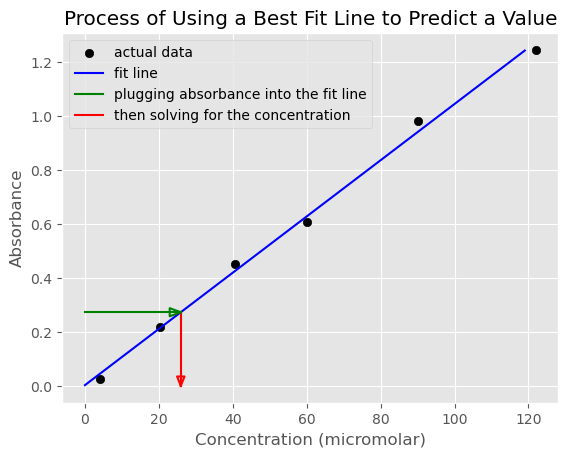

In [53]:
plt.scatter(abs_at_lambda_max[0], abs_at_lambda_max[1], color = 'black', label = 'actual data')
plt.plot(np.arange(0, 120), [slope * x + intercept for x in np.arange(0, 120)], color = 'blue', label = 'fit line')
plt.plot([0, unknown_conc_black], [unknown_abs_black, unknown_abs_black], color = 'green', label = 'plugging absorbance into the fit line')
plt.plot([unknown_conc_black, unknown_conc_black], [0, unknown_abs_black], color = 'red', label = 'then solving for the concentration')
plt.plot([unknown_conc_black, unknown_conc_black-3, unknown_conc_black-3, unknown_conc_black], [unknown_abs_black, unknown_abs_black+0.015, unknown_abs_black-0.015, unknown_abs_black], color = 'green')
plt.plot([unknown_conc_black, unknown_conc_black+1, unknown_conc_black-1, unknown_conc_black], [0, 0.035, +0.035, 0], color = 'red')
plt.legend()
plt.title('Process of Using a Best Fit Line to Predict a Value')
plt.ylabel('Absorbance')
plt.xlabel('Concentration (micromolar)')
plt.show()

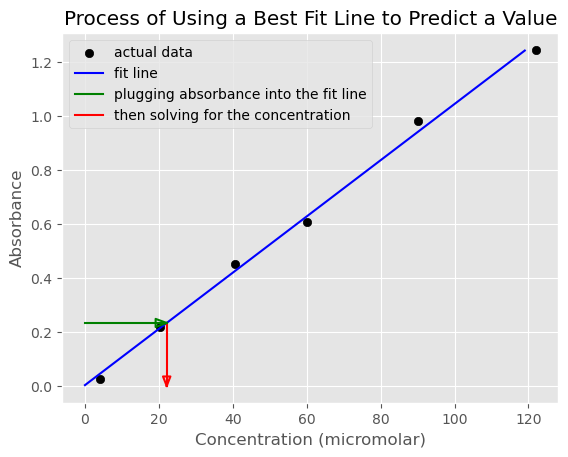

In [50]:
plt.scatter(abs_at_lambda_max[0], abs_at_lambda_max[1], color = 'black', label = 'actual data')
plt.plot(np.arange(0, 120), [slope * x + intercept for x in np.arange(0, 120)], color = 'blue', label = 'fit line')
plt.plot([0, unknown_conc_green], [unknown_abs_green, unknown_abs_green], color = 'green', label = 'plugging absorbance into the fit line')
plt.plot([unknown_conc_green, unknown_conc_green], [0, unknown_abs_green], color = 'red', label = 'then solving for the concentration')
plt.plot([unknown_conc_green, unknown_conc_green-3, unknown_conc_green-3, unknown_conc_green], [unknown_abs_green, unknown_abs_green+0.015, unknown_abs_green-0.015, unknown_abs_green], color = 'green')
plt.plot([unknown_conc_green, unknown_conc_green+1, unknown_conc_green-1, unknown_conc_green], [0, 0.035, +0.035, 0], color = 'red')
plt.legend()
plt.title('Process of Using a Best Fit Line to Predict a Value')
plt.ylabel('Absorbance')
plt.xlabel('Concentration (micromolar)')
plt.show()

Now, we must admit that we LIED to you. That is, we had secretly carried out a 100x dilution of the tea before you analyzed it. Multiply the predicted concentration by 100 to get the original concentration of tea **in micromolar**, then carry out the necessary conversion to turn it into **molar**.

In [48]:
actual_conc_black = unknown_conc_black*100/10**6
actual_conc_green = unknown_conc_green*100/10**6
print('concentration of caffeine in black tea:', actual_conc_black, 'moles/Liter')
print('concentration of caffeine in green tea:', actual_conc_green, 'moles/Liter')

concentration of caffeine in black tea: 0.00259326564485 moles/Liter
concentration of caffeine in green tea: 0.00221209371156 moles/Liter


## Step 6: Determination of the Unknown Mass
Remember that the concentration of the soluton represents the following:
$$c = \frac{moles\; of\; caffeine}{liter\; of\; water}$$
Many tea companies will list the caffeine as some number of milligrams in a serving size (often 8 fluid ounces). Your job here is to convert the concentration from moles per liter to milligrams per serving size.

Hints:
* As always, don't rush. Focus on converting the numerator first, and then the denominator.
* If you are unsure on how to tackle this kind of problem, head to [this page](https://temple.2i2c.cloud/hub/user-redirect/lab/tree/STEM%20UP%20prototypes/UnitConvert.ipynb).
* You'll need to know the molar mass of caffeine. The molecular formula is $C_8H_{10}N_4O_2$. Once you find the molar mass, that becomes __ grams = 1 mole.

It always helps to list out the relevant conversion factors. 

**Numerator:** To go from moles of caffeine to milligrams of caffeine:
* 1 mole of caffeine = __ grams of caffeine (You'll need to calculate this!)
* 1 gram of caffeine = __ milligrams of caffeine

**Denominator:** To go from liters of water to 8 fl oz:
* 1 liter = __ fl oz
* 1 serving size = __ fl oz (best to check with the website)

In [49]:
# 194.19 g/mol
mass_black = actual_conc_black*194.19*1000*8/33.814
mass_green = actual_conc_green*194.19*1000*8/33.814
print('black tea:', mass_black, 'milligrams per serving size')
print('green tea:', mass_green, 'milligrams per serving size')

black tea: 119.142664121 milligrams per serving size
green tea: 101.630443685 milligrams per serving size


Now check with the caffeine level on the company's website. Does your value sit within their range? If not, what could have caused this discrepancy?

**<Double-click this cell and replace this line with your answer!>**